## Setting up required libraries

In [68]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
from tqdm import tqdm
from scipy import interpolate
import pickle
import re
import os
import boost_histogram as bh

# Use CMS style from mplhep
plt.style.use(hep.style.CMS)

import matplotlib.pylab as pylab
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

%matplotlib inline
%config InlineBackend.figure_format='retina'

## Looking at Ntuple content

In [2]:
filepath="/eos/home-r/rhashmi/work/hscp/CMSSW_10_6_39/src/genTrackEcalAnalyzer/AOD_trackSel_wDedx_wEB/Q24_M1400.root"
f = uproot.open(filepath)   

In [5]:
f['Ntuple'].keys()

['Run',
 'Event',
 'GenPart.',
 'GenPart./GenPart.TObject',
 'GenPart./GenPart.TObject/GenPart.TObject.fUniqueID',
 'GenPart./GenPart.TObject/GenPart.TObject.fBits',
 'GenPart./GenPart.pt',
 'GenPart./GenPart.eta',
 'GenPart./GenPart.phi',
 'GenPart./GenPart.id',
 'Tracks.',
 'Tracks./Tracks.TObject',
 'Tracks./Tracks.TObject/Tracks.TObject.fUniqueID',
 'Tracks./Tracks.TObject/Tracks.TObject.fBits',
 'Tracks./Tracks.pt',
 'Tracks./Tracks.beta',
 'Tracks./Tracks.eta',
 'Tracks./Tracks.phi',
 'Tracks./Tracks.deltaR',
 'Tracks./Tracks.qoverp',
 'Tracks./Tracks.lambda',
 'Tracks./Tracks.dxy',
 'Tracks./Tracks.dsz',
 'Tracks./Tracks.chisq',
 'Tracks./Tracks.ndof',
 'Tracks./Tracks.validHitsFrac',
 'Tracks./Tracks.charge',
 'Tracks./Tracks.trackQual',
 'Tracks./Tracks.trackAlgo',
 'Tracks./Tracks.validHitsNum',
 'Tracks./Tracks.hasDedxRef',
 'EcalRecHits.',
 'EcalRecHits./EcalRecHits.TObject',
 'EcalRecHits./EcalRecHits.TObject/EcalRecHits.TObject.fUniqueID',
 'EcalRecHits./EcalRecHits.TObje

In [21]:
f['Ntuple']['EcalRecHits./EcalRecHits.energy'].array(library='np')

array([<STLVector [[0.009273739, 0.046843387, 0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.017184995, 0.041647762], ...] at 0x7ff2c4151b90>,
       <STLVector [[0.0, 0.0013705757, 0.0, 0.02631704, ..., 0.0, 5.1248083, 0.02386873, 0.1334815], ...] at 0x7ff2aeb0f4d0>,
       <STLVector [] at 0x7ff2d801a490>, ...,
       <STLVector [] at 0x7ff2aebc0910>,
       <STLVector [[0.0, 0.0, 0.0, 0.0, 0.017655395, ..., 0.0, 0.03684878, 0.0, 0.10303337, 0.020378716], ...] at 0x7ff2aebc0a50>,
       <STLVector [[0.10386186, 0.0, 0.0, 0.0, 0.015044896, 0.07592315, ..., 0.0, 0.0, 0.0, 0.0, 0.0], ...] at 0x7ff2aebc0ad0>],
      dtype=object)

In [3]:
a = f['Ntuple']['EcalRecHits./EcalRecHits.energy'].array(library='np')
b = f['Ntuple']['EcalRecHits./EcalRecHits.time'].array(library='np')
c = f['Ntuple']['EcalRecHits./EcalRecHits.deltaR'].array(library='np')

[[0.0, 0.0, 0.0, 0.0, 0.11244468, ..., 0.0, 0.0012659577, 0.028423205, 0.0, 0.0]] [[-22.475956, -55.594852, -0.9274, -0.9274, ..., -0.9274, -0.9274, -0.9274, -0.9274]] [[0.05647652, 0.040852547, 0.026086217, ..., 0.054174736, 0.04999323, 0.052991427]]
[[0.12576547, 0.11241797, 0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0555573, 0.1211167, 0.0]] [[16.803091, -0.9274, -0.9274, -0.9274, ..., -0.9274, -0.9274, -0.9274, -0.9274]] [[0.049095683, 0.04251694, 0.041089337, ..., 0.033967644, 0.040547147, 0.053089418]]
[[0.0, 0.0, 0.034460507, 0.13814242, ..., 0.0, 0.0, 0.118479475, 0.0014511647]] [[-44.581394, -0.9274, -42.535015, -0.9274, ..., -0.9274, -0.9274, 2.2584863, -0.9274], ...] [[0.05498476, 0.044375114, 0.03759625, ..., 0.037161868, 0.037709914, 0.04647379]]
[[18.669767]] [[5.873768]] [[0.0042940816]]
[[]] [[]] [[]]
[[0.023599189, 0.0, 0.0, 0.0, 0.0, 0.024285765, ..., 0.10248209, 0.0, 0.0, 0.0, 0.0]] [[-0.9274, -0.9274, -0.9274, -0.9274, ..., -0.9274, 64.170425, 4.9601607, -0.9274]] [[0.04887912

Entries: 1284


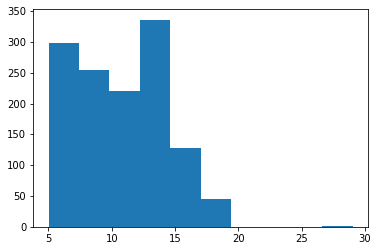

In [16]:
energy = []
time = []
dr = []
for i,j,k in zip(a,b,c):
    if len(i) == 0:
        continue
    print(i,j,k)
    for i1,j1,k1 in zip(i[0],j[0],k[0]):
        if k1 < .1 and i1 > 5:
            energy.append(i1)
            time.append(j1)
            dr.append(k1)
            #print(f"Energy: {i1}, time: {j1}, dR: {k1}")
    #print("new")
    
plt.hist(energy)
print(f"Entries: {len(energy)}")
plt.show()

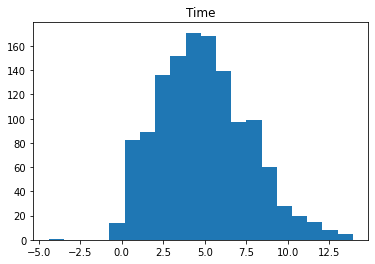

In [12]:
plt.hist(time, bins=20)
plt.title("Time")
plt.show()

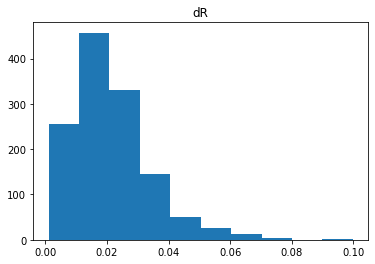

In [13]:
plt.hist(dr)
plt.title("dR")
plt.show()

In [4]:
f["Ntuple"]["Tracks./Tracks.pt"].array()

<Array [[48.3], [45.7], [90], ..., [61.8], [16.1]] type='2000 * var * float32'>

In [5]:
f['Ntuple']['EcalRecHits./EcalRecHits.energy'].array()

<Array [[[0, 0, 0, 0, ..., 0.0284, 0, 0]], ...] type='2000 * var * var * fl...'>

In [3]:
tracks_pt = f["Ntuple"]["Tracks./Tracks.pt"].array(library="np")
tracks_eta = f["Ntuple"]["Tracks./Tracks.eta"].array(library="np")
tracks_deltaR = f["Ntuple"]["Tracks./Tracks.deltaR"].array(library="np")
tracks_hasDedx = f["Ntuple"]["Tracks./Tracks.hasDedxRef"].array(library="np")

ecal_energy = f['Ntuple']['EcalRecHits./EcalRecHits.energy'].array(library='np')
ecal_energyErr = f['Ntuple']['EcalRecHits./EcalRecHits.energyErr'].array(library='np')

ecal_time = f['Ntuple']['EcalRecHits./EcalRecHits.time'].array(library='np')
ecal_timeErr = f['Ntuple']['EcalRecHits./EcalRecHits.timeErr'].array(library='np')
ecal_timeErrValid = f['Ntuple']['EcalRecHits./EcalRecHits.timeErrValid'].array(library='np')

ecal_deltaR = f['Ntuple']['EcalRecHits./EcalRecHits.deltaR'].array(library='np')
ecal_rechitFlag = f['Ntuple']['EcalRecHits./EcalRecHits.rechitFlag'].array(library='np')

In [17]:
for i in range(len(tracks_pt)):
    if(len(tracks_pt[i])>1):
        print(tracks_pt[i], tracks_deltaR[i])
        for j,k in zip (ecal_energy[i],ecal_time[i]):
            print(f"E {j}")
            print(f"T {k}")
        print("----------------------------------")

[107.45179     5.4866548] [0.00027929 0.05118219]
E [0.0, 0.0, 0.0, 0.0, 0.0, ..., 0.08205224, 0.0006729064, 0.0, 0.053985804]
T [4.3368225, -0.9274, -0.9274, -87.41086, ..., -0.9274, -0.9274, -0.9274, -0.9274]
E [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..., 0.045210186, 0.00852391, 0.0, 0.018259766, 0.0]
T [4.3368225, -0.9274, -0.9274, -87.41086, ..., 22.875072, -0.9274, -31.269003]
----------------------------------
[125.21988     6.7161098] [0.00020727 0.00783154]
E [15.764796]
T [3.7021718]
E [15.764796]
T [3.7021718]
----------------------------------
[ 5.783282 61.127907] [0.02767333 0.00037562]
E [2.8744237, 14.189698, 1.6393881]
T [9.069617, 8.519873, -4.470871]
E [2.8744237, 14.189698, 0.44077396]
T [9.069617, 8.519873, -8.195599]
----------------------------------
[ 22.725613 101.55944 ] [0.08627117 0.00108701]
E [0.269765, 0.0, 16.42835, 0.07035473, ..., 0.0, 0.12843786, 0.049026597, 0.0]
T [-0.9274, -0.9274, 5.316925, -55.7132, ..., -0.9274, -7.766768, 33.323753, -0.9274]
E [0.171814

In [4]:
total_tracks = 0
total_tracks_wdedx = 0
total_tracks_eta_EB = 0
total_tracks_eta_EB_wdedx = 0
EB_eta = 1.479

Energy = []
EnergyErr = []
Time = []
TimeErr = []
TimeErrValid = []
DeltaR = []
RechitFlags = []

for (pt_array, track_dR_array, track_eta_array, track_hasDedx, \
     energy_array, energyErr_array, \
     time_array, timeErr_array, timeErrValid_array, \
     ecal_dR_array, rechitFlag_array) \
        in zip(tracks_pt, tracks_deltaR, tracks_eta, tracks_hasDedx, \
               ecal_energy, ecal_energyErr, \
               ecal_time, ecal_timeErr, ecal_timeErrValid, \
               ecal_deltaR, ecal_rechitFlag):

    sel_energy       = []
    sel_energyErr    = []
    sel_time         = []
    sel_timeErr      = []
    sel_timeErrValid = []
    sel_dR           = []
    sel_rechitFlag   = []
    
    # Only saved tracks with pt>5 and ecal hits assocciated with them so no need for this
    #track_dR_array = track_dR_array[ (pt_array>5) ]
    #pt_array = pt_array[ (pt_array>5) ]
    
    if pt_array.size == 0:
        continue
    
    min_idx = np.argmin(track_dR_array)
    
    total_tracks += 1
    has_dedxFlag = 0
    if (track_hasDedx[min_idx]):
        total_tracks_wdedx += 1
        has_dedxFlag = 1
    if (track_eta_array[min_idx] < EB_eta):
        total_tracks_eta_EB += 1
        total_tracks_eta_EB_wdedx += has_dedxFlag
    
    if min_idx < len(energy_array): 
        sel_energy       = energy_array[min_idx]
        sel_energyErr    = energyErr_array[min_idx]
        sel_time         = time_array[min_idx]
        sel_timeErr      = timeErr_array[min_idx]
        sel_timeErrValid = timeErrValid_array[min_idx]
        sel_dR           = ecal_dR_array[min_idx]
        sel_rechitFlag   = rechitFlag_array[min_idx]
        
    # If there were EB hits associated with the tracks
    if len(sel_energy) == 0:
        continue
        
    # Quality checks
    mask = (sel_timeErrValid[:] == True) & (sel_energyErr[:] < .5) & (sel_timeErr[:] < 1)
    sel_energy       = sel_energy[mask]
    sel_energyErr    = sel_energyErr[mask]
    sel_time         = sel_time[mask]
    sel_timeErr      = sel_timeErr[mask]
    sel_timeErrValid = sel_timeErrValid[mask]
    sel_dR           = sel_dR[mask]
    sel_rechitFlag   = sel_rechitFlag[mask]

    if len(sel_energy) == 0:
        continue
    
    ecal_idx = np.argmax(sel_energy)
    Energy.append(sel_energy[ecal_idx])
    EnergyErr.append(sel_energyErr[ecal_idx])
    Time.append(sel_time[ecal_idx])
    TimeErr.append(sel_timeErr[ecal_idx])
    TimeErrValid.append(sel_timeErrValid[ecal_idx])
    DeltaR.append(sel_dR[ecal_idx])
    RechitFlags.append(sel_rechitFlag[ecal_idx])

print(f'ratio of selected tracks w dedx: {total_tracks_wdedx/total_tracks}')
print(f'ratio all tracks: {len(Energy)/total_tracks}')
print(f'ratio all tracks w dedx: {len(Energy)/total_tracks_wdedx}')
print(f'ratio EB tracks:  {len(Energy)/total_tracks_eta_EB}')
print(f'ratio EB tracks e dedx:  {len(Energy)/total_tracks_eta_EB_wdedx}')

ratio of selected tracks w dedx: 0.9938513135830073
ratio all tracks: 0.6042481833426495
ratio all tracks w dedx: 0.6079865016872891
ratio EB tracks:  0.6898532227185705
ratio EB tracks e dedx:  0.6929487179487179


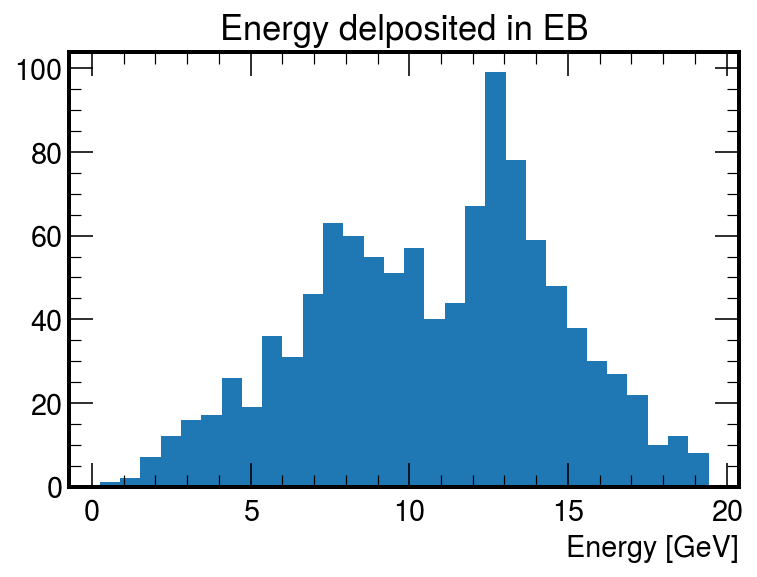

In [16]:
plt.hist(Energy,bins=30)
plt.title('Energy delposited in EB')
plt.xlabel('Energy [GeV]')
plt.show()

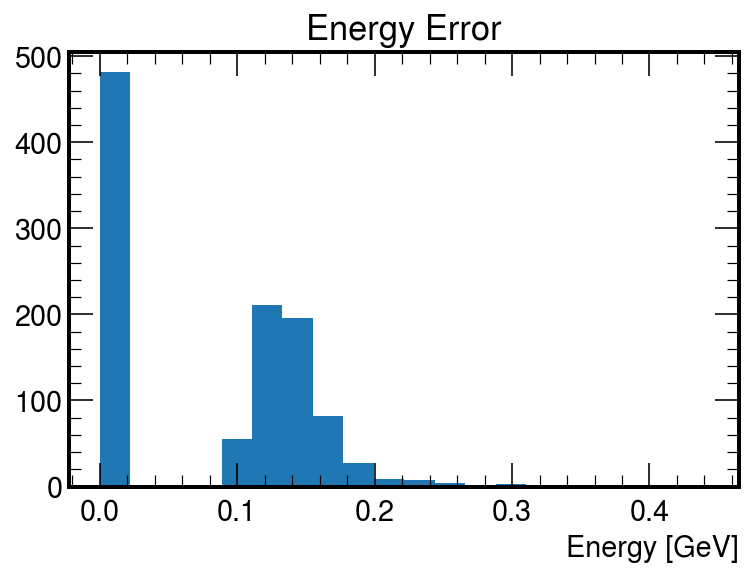

In [6]:
plt.hist(EnergyErr,bins=20)
plt.title('Energy Error')
plt.xlabel('Energy [GeV]')
plt.show()

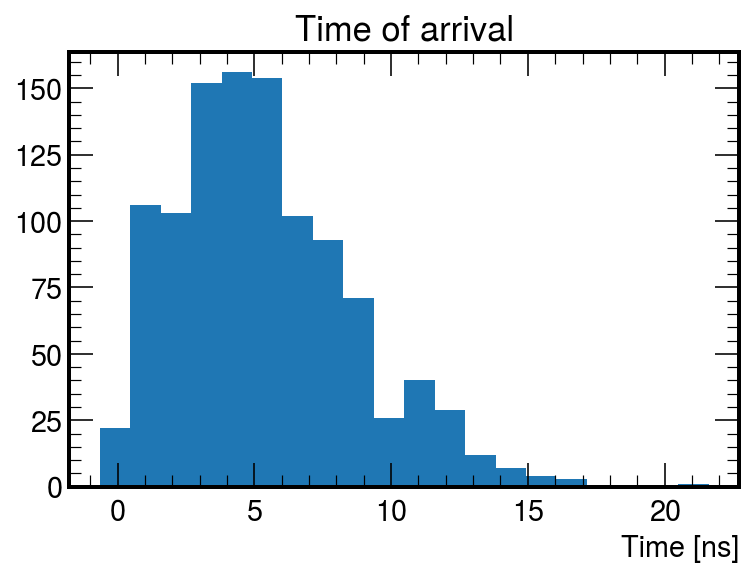

In [15]:
plt.hist(Time,bins=20)
plt.title('Time of arrival')
plt.xlabel('Time [ns]')
plt.show()

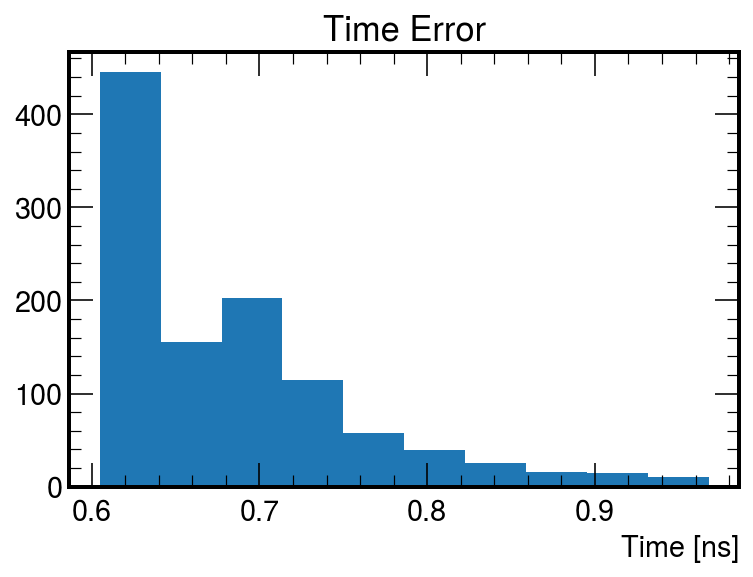

In [13]:
plt.hist(TimeErr,bins=10)
plt.title('Time Error')
plt.xlabel('Time [ns]')
plt.show()

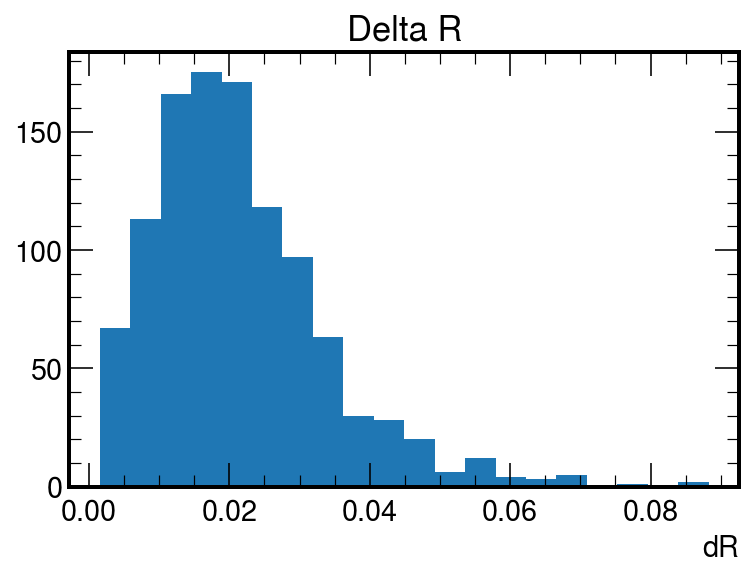

In [10]:
plt.hist(DeltaR,bins=20)
plt.title('Delta R')
plt.xlabel('dR')
plt.show()

# Histogram Producer
Working on a histogram producer to save all desired histograms to be looked at later

In [52]:
def ExtractFancyEnergy(chosenCoords, energy, iEta, iPhi):
    E_neighborMax = 0
    E4 = 0
    E8 = 0
    
    for (e, ieta, iphi) in zip (energy, iEta, iPhi):
        dieta = abs(ieta - chosenCoords[0])
        diphi = abs(iphi - chosenCoords[1])
        
        if ( (dieta>1) or (diphi>1) ):
            continue
            
        if ( (dieta==0) and (diphi==0) ):
            continue
            
        if e > E_neighborMax:
            E_neighborMax = e
            
        if ( (dieta + diphi == 1) ):
            E4 += e
        
        E8 += e
    
    return (E_neighborMax, E4, E8)

def HistogramProducer(pt, eta, t_dR, has_dedx, dedx, energy, energyErr, \
                      time, timeErr, timeErrValid, e_dR, iEta, iPhi):
    total_tracks = 0
    total_tracks_wdedx = 0
    total_tracks_eta_EB = 0
    total_tracks_eta_EB_wdedx = 0
    EB_eta = 1.479

    Energy = []
    EnergyErr = []
    Time = []
    TimeErr = []
    TimeErrValid = []
    DeltaR = []
    PT = []
    DEDX = []
    E2 = []
    E4 = []
    E3x3 = []
    #RechitFlags = []

    for (pt_array, track_dR_array, track_eta_array, track_hasDedx, track_dedx, \
         energy_array, energyErr_array, \
         time_array, timeErr_array, timeErrValid_array, \
         ecal_dR_array, ecal_iEta, ecal_iPhi) \
            in zip(pt, t_dR, eta, has_dedx, dedx, \
                   energy, energyErr, \
                   time, timeErr, timeErrValid, \
                   e_dR, iEta, iPhi):

        sel_energy       = []
        sel_energyErr    = []
        sel_time         = []
        sel_timeErr      = []
        sel_timeErrValid = []
        sel_dR           = []
        #sel_rechitFlag   = []

        # Only saved tracks with pt>5 and ecal hits assocciated with them so no need for this
        #track_dR_array = track_dR_array[ (pt_array>5) ]
        #pt_array = pt_array[ (pt_array>5) ]

        if pt_array.size == 0:
            continue

        min_idx = np.argmin(track_dR_array)

        total_tracks += 1
        has_dedxFlag = 0
        if (track_hasDedx[min_idx]):
            total_tracks_wdedx += 1
            has_dedxFlag = 1
        if (track_eta_array[min_idx] < EB_eta):
            total_tracks_eta_EB += 1
            total_tracks_eta_EB_wdedx += has_dedxFlag

        if min_idx < len(energy_array): 
            sel_energy       = energy_array[min_idx]
            sel_energyErr    = energyErr_array[min_idx]
            sel_time         = time_array[min_idx]
            sel_timeErr      = timeErr_array[min_idx]
            sel_timeErrValid = timeErrValid_array[min_idx]
            sel_dR           = ecal_dR_array[min_idx]
            sel_iEta         = ecal_iEta[min_idx]
            sel_iPhi         = ecal_iPhi[min_idx]
            #sel_rechitFlag   = rechitFlag_array[min_idx]

        # If there were no EB hits associated with the tracks
        if len(sel_energy) == 0:
            continue

        E = sel_energy
        Eta = sel_iEta
        Phi = sel_iPhi
        
        # Quality checks
        mask = (sel_timeErrValid[:] == True) & (sel_energyErr[:] < .5) & (sel_timeErr[:] < 1) & \
                (sel_energy[:] > 5) & (sel_time[:] > 2)
        sel_energy       = sel_energy[mask]
        sel_energyErr    = sel_energyErr[mask]
        sel_time         = sel_time[mask]
        sel_timeErr      = sel_timeErr[mask]
        sel_timeErrValid = sel_timeErrValid[mask]
        sel_dR           = sel_dR[mask]
        sel_iEta         = sel_iEta[mask]
        sel_iPhi         = sel_iPhi[mask] 
        #sel_rechitFlag   = sel_rechitFlag[mask]

        # In case the quality mask killed everything
        if len(sel_energy) == 0:
            continue

        PT.append(pt_array[min_idx])
        DEDX.append(track_dedx[min_idx])
        
        ecal_idx = np.argmax(sel_energy)
        
        E_neighborMax_, E4_, E8_ = ExtractFancyEnergy( (sel_iEta[ecal_idx], sel_iPhi[ecal_idx]), \
                                                      E, Eta, Phi)
        
        temp_e = sel_energy[ecal_idx]
        Energy.append(temp_e)
        EnergyErr.append(sel_energyErr[ecal_idx])
        Time.append(sel_time[ecal_idx])
        TimeErr.append(sel_timeErr[ecal_idx])
        TimeErrValid.append(sel_timeErrValid[ecal_idx])
        DeltaR.append(sel_dR[ecal_idx])
        E2.append(E_neighborMax_ + temp_e)
        E4.append(E4_)
        E3x3.append(E8_ + temp_e)
        #RechitFlags.append(sel_rechitFlag[ecal_idx])
        
    # Make boost histograms
    hist_Energy  = bh.Histogram(bh.axis.Regular(120, 0, 60))
    hist_dR      = bh.Histogram(bh.axis.Regular(20, 0, 0.1))
    hist_Time    = bh.Histogram(bh.axis.Regular(50, -5, 20))
    hist_E2      = bh.Histogram(bh.axis.Regular(120, 0, 60))
    hist_E4      = bh.Histogram(bh.axis.Regular(120, 0, 60))
    hist_E3x3    = bh.Histogram(bh.axis.Regular(120, 0, 60))
    
    hist_Evpt    = bh.Histogram(bh.axis.Regular( 40, 0, 400), \
                                bh.axis.Regular(60, 0, 30))
    hist_E2vpt   = bh.Histogram(bh.axis.Regular( 40, 0, 400), \
                                bh.axis.Regular(60, 0, 30))
    hist_E3x3vpt = bh.Histogram(bh.axis.Regular( 40, 0, 400), \
                                bh.axis.Regular(60, 0, 30))
    hist_Dedxvpt = bh.Histogram(bh.axis.Regular( 60, 0, 600), \
                                bh.axis.Regular(50, 0, 50))
    hist_E2vDedx = bh.Histogram(bh.axis.Regular( 60, 0, 50), \
                                bh.axis.Regular(60, 0, 30))
    hist_EvE4    = bh.Histogram(bh.axis.Regular( 30, 0, 30), \
                                bh.axis.Regular(60, 0, 30))
    
    hist_Energy.fill(Energy)
    hist_dR.fill(DeltaR)
    hist_Time.fill(Time)
    hist_E2.fill(E2)
    hist_E4.fill(E4)
    hist_E3x3.fill(E3x3)
    
    hist_Evpt.fill(PT, Energy)
    hist_E2vpt.fill(PT, E2)
    hist_E3x3vpt.fill(PT, E3x3)
    hist_Dedxvpt.fill(PT, DEDX)
    hist_E2vDedx.fill(DEDX, E2)
    hist_EvE4.fill(E4, Energy)
    
    return (hist_Energy, hist_Time, hist_dR, hist_E2, hist_E4, hist_E3x3, \
            hist_Evpt, hist_E2vpt, hist_E3x3vpt, hist_Dedxvpt, hist_E2vDedx, hist_EvE4, \
            len(Energy)/total_tracks, len(Energy)/total_tracks_eta_EB)

def EcalSelectionHistograms(directory, output_pkl="Histograms/EcalSel_histograms_ptcut5_E5T2cut.pkl"):
    filename_pattern = re.compile(r"Q(\d+)_M(\d+)\.root")   
    files = [f for f in os.listdir(directory) if filename_pattern.match(f)]
    
    histograms = {}
    
    for filename in tqdm(files, desc="Processing files", unit="file"):
        match = filename_pattern.match(filename)

        charge = int(match.group(1)) // 3
        mass = int(match.group(2))
        
        filepath = os.path.join(directory, filename)
        with uproot.open(filepath) as f:
            tracks_pt = f["Ntuple"]["Tracks./Tracks.pt"].array(library="np")
            tracks_eta = f["Ntuple"]["Tracks./Tracks.eta"].array(library="np")
            tracks_deltaR = f["Ntuple"]["Tracks./Tracks.deltaR"].array(library="np")
            tracks_hasDedx = f["Ntuple"]["Tracks./Tracks.hasDedxRef"].array(library="np")
            tracks_dedx = f["Ntuple"]["Tracks./Tracks.dedx"].array(library="np")

            ecal_energy = f['Ntuple']['EcalRecHits./EcalRecHits.energy'].array(library='np')
            ecal_energyErr = f['Ntuple']['EcalRecHits./EcalRecHits.energyErr'].array(library='np')

            ecal_time = f['Ntuple']['EcalRecHits./EcalRecHits.time'].array(library='np')
            ecal_timeErr = f['Ntuple']['EcalRecHits./EcalRecHits.timeErr'].array(library='np')
            ecal_timeErrValid = f['Ntuple']['EcalRecHits./EcalRecHits.timeErrValid'].array(library='np')

            ecal_deltaR = f['Ntuple']['EcalRecHits./EcalRecHits.deltaR'].array(library='np')
            #ecal_rechitFlag = f['Ntuple']['EcalRecHits./EcalRecHits.rechitFlag'].array(library='np')
            
            ecal_iEta = f['Ntuple']['EcalRecHits./EcalRecHits.iEta'].array(library='np')
            ecal_iPhi = f['Ntuple']['EcalRecHits./EcalRecHits.iPhi'].array(library='np')
            
            hist_Energy, hist_Time, hist_dR, hist_E2, hist_E4, hist_E3x3, \
            hist_Evpt , hist_E2vpt, hist_E3x3vpt, hist_Dedxvpt, hist_E2vDedx, hist_EvE4, \
            frac_trk_EB, frac_trk_EB_eta = \
                HistogramProducer(tracks_pt, tracks_eta, tracks_deltaR, tracks_hasDedx, tracks_dedx, \
                                  ecal_energy, ecal_energyErr, \
                                  ecal_time, ecal_timeErr, ecal_timeErrValid, ecal_deltaR, \
                                  ecal_iEta, ecal_iPhi)
            
            histograms[f"Q{charge}_M{mass}"]= {'Energy': hist_Energy, \
                                               'Time': hist_Time, \
                                               'deltaR': hist_dR, \
                                               'E2': hist_E2, \
                                               'E4': hist_E4, \
                                               'E3x3': hist_E3x3, \
                                               'EvsPt': hist_Evpt, \
                                               'E2vsPt': hist_E2vpt, \
                                               'E3x3vsPt': hist_E3x3vpt, \
                                               'DedxvsPt': hist_Dedxvpt, \
                                               'E2vsDedx': hist_E2vDedx, \
                                               'EvsE4': hist_EvE4, \
                                               'frac_trkEB': frac_trk_EB, \
                                               'frac_trkEB_eta': frac_trk_EB_eta }

    with open(output_pkl, "wb") as pkl_file:
        pickle.dump(histograms, pkl_file)

In [53]:
EcalSelectionHistograms('/eos/user/r/rhashmi/work/hscp/CMSSW_10_6_39/src/genTrackEcalAnalyzer/AOD_trackSel_wDedx_wEB/')

Processing files: 100%|██████████| 284/284 [04:17<00:00,  1.10file/s]


In [22]:
EcalSelectionHistograms('/eos/user/r/rhashmi/work/hscp/CMSSW_10_6_39/src/genTrackEcalAnalyzer/AOD_trackSel_wDedx_wEB/')

Processing files: 100%|██████████| 282/282 [04:26<00:00,  1.06file/s]


# Plotting histograms

In [25]:
cls = ['Blues', 'Reds', 'Greens', 'Purples']

def plot_EvsPt_histograms(data, charges, masses):
    #cmap = plt.get_cmap('viridis').copy()
    #cmap.set_under('white')
    plt.figure(figsize=(10, 7))
    c = [plt.get_cmap(j).copy() for j in cls]
    for j in c:
        j.set_bad(alpha=0)

    #fig, ax = plt.subplots()

    i = 0
    for charge in charges:
        for mass in masses:
            key = f'Q{charge}_M{mass}'
            if key in data:
                hist = data[key]['EvsPt']
                counts = hist.view()
                m_masked = np.ma.masked_where(counts == 0, counts)
                x_edges = hist.axes[0].edges
                y_edges = hist.axes[1].edges

                #mesh = ax.pcolormesh(*hist.axes.edges.T, hist.view().T)
                #fig.colorbar(mesh)
                
                # Plot the 2D histogram
                plt.pcolormesh(
                    x_edges,
                    y_edges,
                    m_masked.T,
                    #counts.T,
                    #shading='auto',
                    cmap=c[i],
                    #alpha=.7,
                    vmin=0,
                    #vmax=10
                    #norm=mcolors.Normalize(vmin=0.1)  # Set a lower bound for colors
                )
                i+=1
            else:
                print(f"Warning: {key} not found in data.")
    
    plt.title('EvsPt Histograms')
    plt.xlabel('Pt')
    plt.ylabel('Energy')
    plt.colorbar(label='Counts')
    plt.legend()
    plt.show()

def contour_from_array(data_array, charges, masses, title):
        
    if data_array.shape != (len(masses), len(charges)):
        raise ValueError("The shape of the data array must match the length of the masses and charges lists.")
    
    charge_grid, mass_grid = np.meshgrid(charges, masses)
    
    valid_points = ~np.isnan(data_array)
    valid_charges = charge_grid[valid_points]
    valid_masses = mass_grid[valid_points]
    valid_values = data_array[valid_points]
    
    grid_z = interpolate.griddata(
        (valid_charges, valid_masses),
        valid_values,
        (charge_grid, mass_grid),
        method='cubic'
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.contourf(charge_grid, mass_grid, grid_z, cmap='viridis', levels=30, extend='both', vmin=0, vmax=.8)
    cbar = fig.colorbar(cax)
    cbar.set_label('Ratio')

    contour_lines = ax.contour(charge_grid, mass_grid, grid_z, colors='k', levels=10)
    ax.clabel(contour_lines, inline=True, fontsize=15, fmt='%1.2f')

    ax.set_xticks(charges)
    ax.set_yticks(masses)
    ax.set_xticklabels(charges)
    ax.set_yticklabels(masses)
    ax.set_xlabel('Charge [e]')
    ax.set_ylabel('Mass (GeV)')
    ax.set_title(title)
    ax.tick_params(axis='x', which='both', pad=10)

    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_label_position('bottom')

    plt.tight_layout()
    plt.show()
    
def plot_frac_trkEB_matrix(data):
    charges = sorted({int(key.split('_')[0][1:]) for key in data.keys()})
    masses = sorted({int(key.split('_')[1][1:]) for key in data.keys()})

    frac_trkEB_matrix = np.zeros((len(masses), len(charges)))
    frac_trkEB_eta_matrix = np.zeros((len(masses), len(charges)))

    for i, mass in enumerate(masses):
        for j, charge in enumerate(charges):
            key = f'Q{charge}_M{mass}'
            if key in data:
                frac_trkEB_matrix[i, j] = data[key]['frac_trkEB']
                frac_trkEB_eta_matrix[i, j] = data[key]['frac_trkEB_eta']
            else:
                frac_trkEB_matrix[i, j] = np.nan
                frac_trkEB_eta_matrix[i, j] = np.nan

    contour_from_array(frac_trkEB_eta_matrix, charges, masses, 'Contour plot of fraction of tracks with matched EB')
    
    return(0)
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    im1 = ax[0].matshow(frac_trkEB_matrix, aspect='auto', cmap='viridis', origin='lower')
    ax[0].set_title('frac_trkEB')
    ax[0].set_xlabel('Charge')
    ax[0].set_ylabel('Mass (GeV)')
    ax[0].set_xticks(range(len(charges)))
    ax[0].set_xticklabels(charges)
    ax[0].set_yticks(range(len(masses)))
    ax[0].set_yticklabels(masses)
    fig.colorbar(im1, ax=ax[0])

    im2 = ax[1].matshow(frac_trkEB_eta_matrix, aspect='auto', cmap='plasma', origin='lower')
    ax[1].set_title('frac_trkEB_eta')
    ax[1].set_xlabel('Charge')
    ax[1].set_ylabel('Mass (GeV)')
    ax[1].set_xticks(range(len(charges)))
    ax[1].set_xticklabels(charges)
    ax[1].set_yticks(range(len(masses)))
    ax[1].set_yticklabels(masses)
    fig.colorbar(im2, ax=ax[1])

    plt.tight_layout()
    plt.show()
    
    #contour_from_array(frac_trkEB_eta_matrix, charges, masses, 'Contour plot of fraction of tracks with matched EB')

In [9]:
cls = ['Blues', 'Reds', 'Greens', 'Purples']

def plot_2Dhistograms_pkl(data, labels, charges, masses):
    
    title, xlabel, ylabel = labels
    
    #cmap = plt.get_cmap('viridis').copy()
    #cmap.set_under('white')
    plt.figure(figsize=(10, 7))
    c = [plt.get_cmap(j).copy() for j in cls]
    for j in c:
        j.set_bad(alpha=0)

    #fig, ax = plt.subplots()

    i = 0
    for charge in charges:
        for mass in masses:
            key = f'Q{charge}_M{mass}'
            if key in data:
                hist = data[key][title]
                counts = hist.view()
                m_masked = np.ma.masked_where(counts == 0, counts)
                x_edges = hist.axes[0].edges
                y_edges = hist.axes[1].edges

                #mesh = ax.pcolormesh(*hist.axes.edges.T, hist.view().T)
                #fig.colorbar(mesh)
                
                # Plot the 2D histogram
                plt.pcolormesh(
                    x_edges,
                    y_edges,
                    m_masked.T,
                    #counts.T,
                    #shading='auto',
                    cmap=c[i],
                    #alpha=.7,
                    vmin=0,
                    #vmax=10
                    #norm=mcolors.Normalize(vmin=0.1)  # Set a lower bound for colors
                )
                i+=1
            else:
                print(f"Warning: {key} not found in data.")
    
    plt.title(f'{title} Histograms')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.colorbar(label='Counts')
    plt.legend()
    plt.show()

In [69]:
with open('Histograms/EcalSel_histograms_ptcut5_E5T2cut.pkl', 'rb') as f:
    data = pickle.load(f)

In [104]:
data

{'Q4_M1800': {'Energy': Histogram(Regular(120, 0, 60), storage=Double()) # Sum: 1002.0,
  'Time': Histogram(Regular(50, -5, 20), storage=Double()) # Sum: 979.0 (1002.0 with flow),
  'deltaR': Histogram(Regular(20, 0, 0.1), storage=Double()) # Sum: 1002.0,
  'E2': Histogram(Regular(120, 0, 60), storage=Double()) # Sum: 1002.0,
  'E4': Histogram(Regular(120, 0, 60), storage=Double()) # Sum: 1002.0,
  'E3x3': Histogram(Regular(120, 0, 60), storage=Double()) # Sum: 1002.0,
  'EvsPt': Histogram(
    Regular(60, 0, 600),
    Regular(60, 0, 30),
    storage=Double()) # Sum: 999.0 (1002.0 with flow),
  'E2vsPt': Histogram(
    Regular(60, 0, 600),
    Regular(60, 0, 30),
    storage=Double()) # Sum: 999.0 (1002.0 with flow),
  'E3x3vsPt': Histogram(
    Regular(60, 0, 600),
    Regular(60, 0, 30),
    storage=Double()) # Sum: 999.0 (1002.0 with flow),
  'DedxvsPt': Histogram(
    Regular(60, 0, 600),
    Regular(50, 0, 50),
    storage=Double()) # Sum: 999.0 (1002.0 with flow),
  'E2vsDedx': H

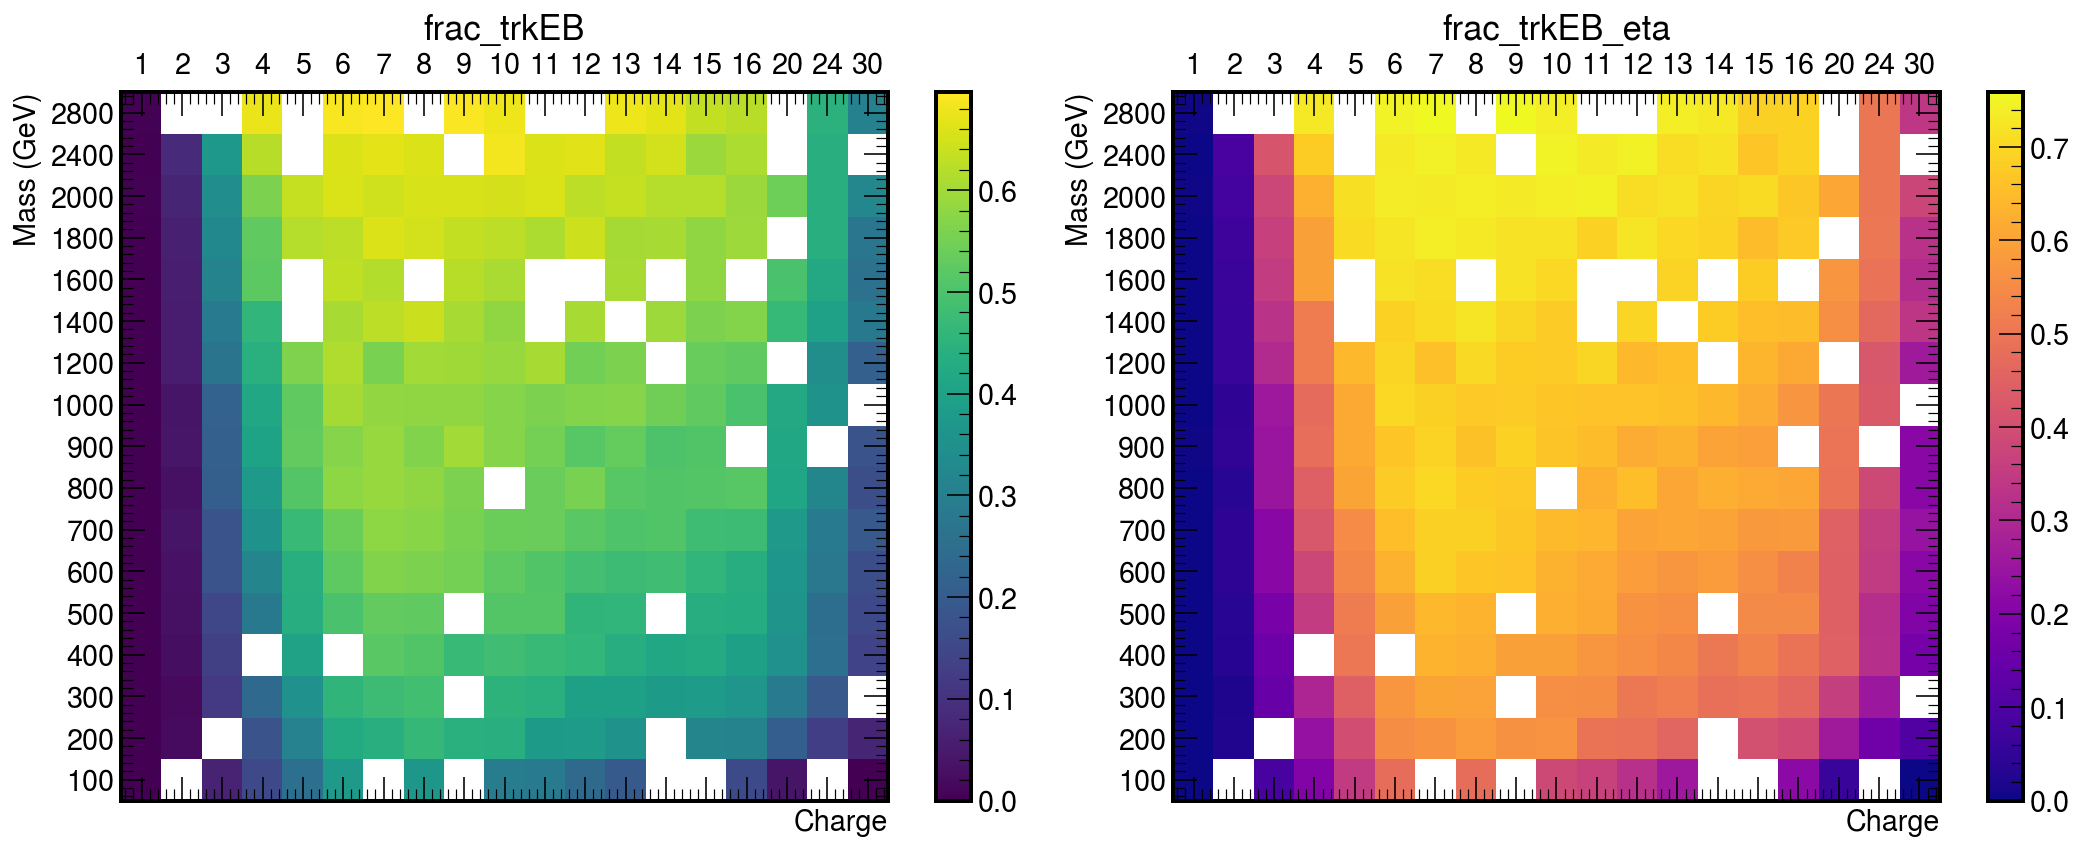

In [24]:
plot_frac_trkEB_matrix(data)

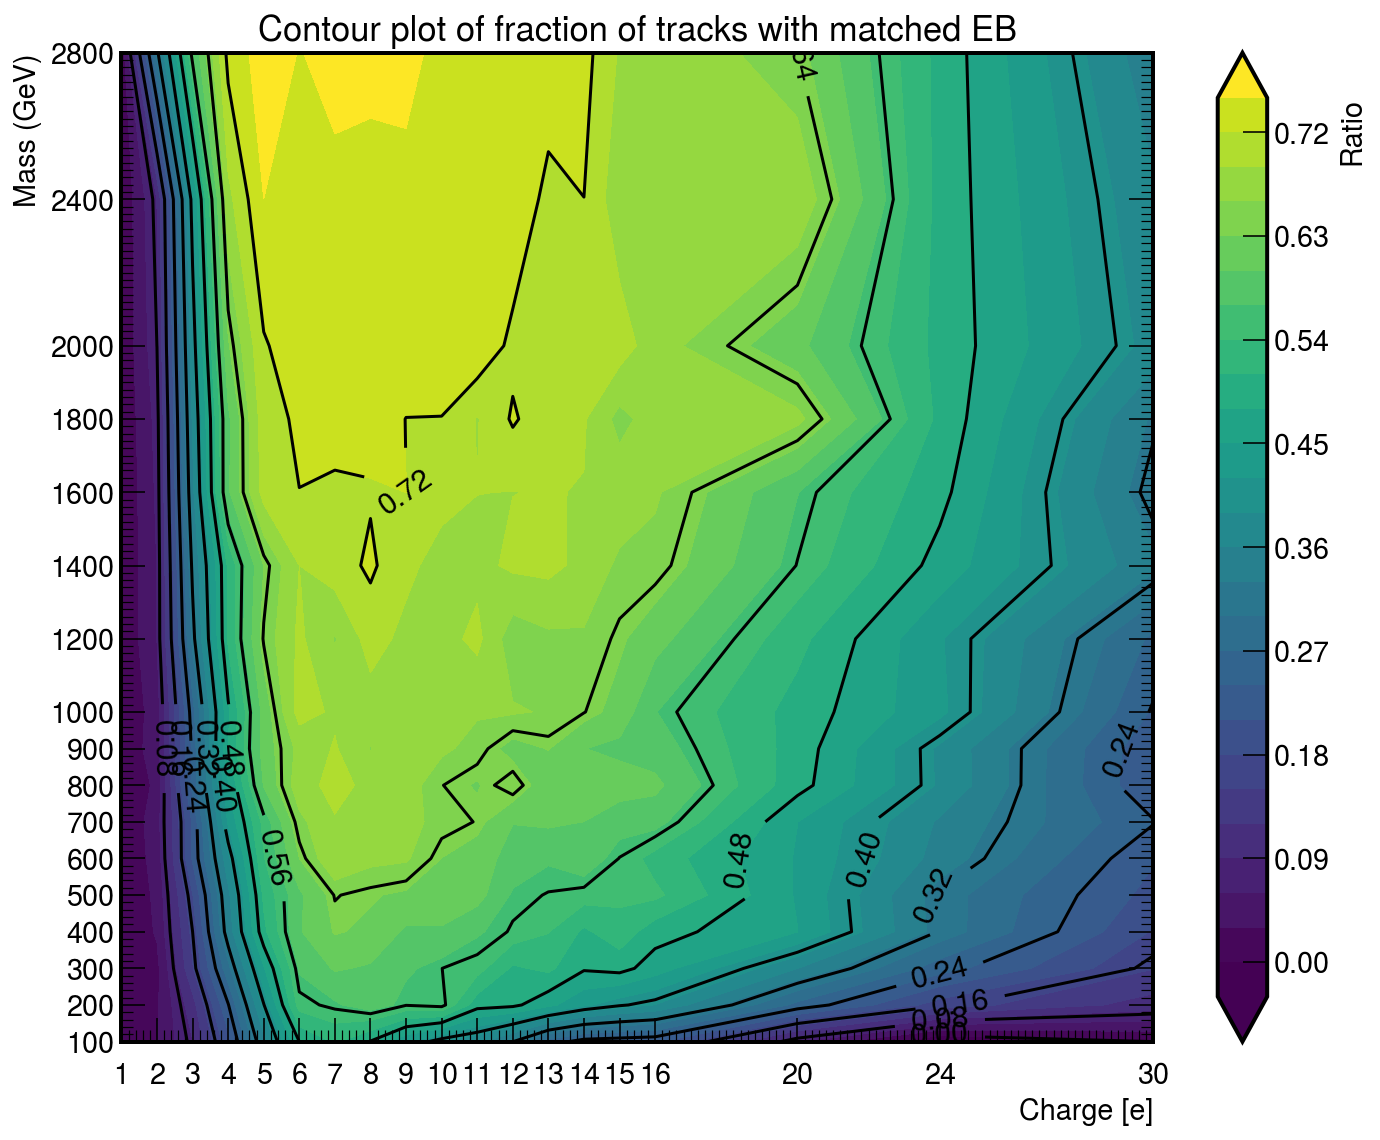

0

In [26]:
plot_frac_trkEB_matrix(data)

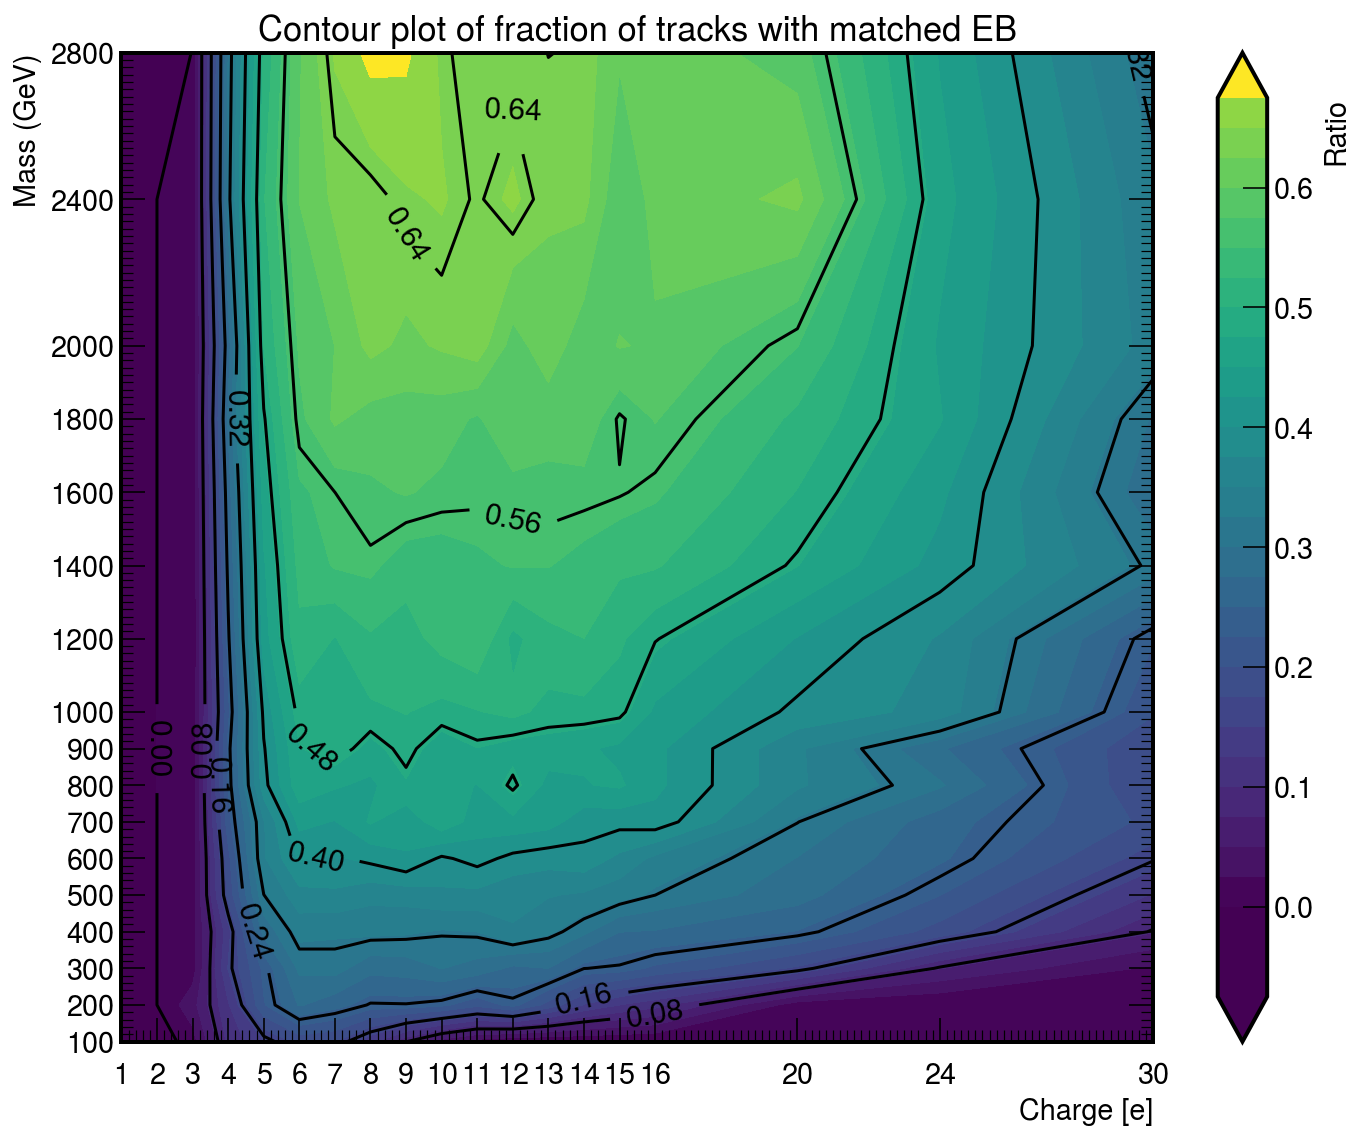

0

In [55]:
plot_frac_trkEB_matrix(data)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


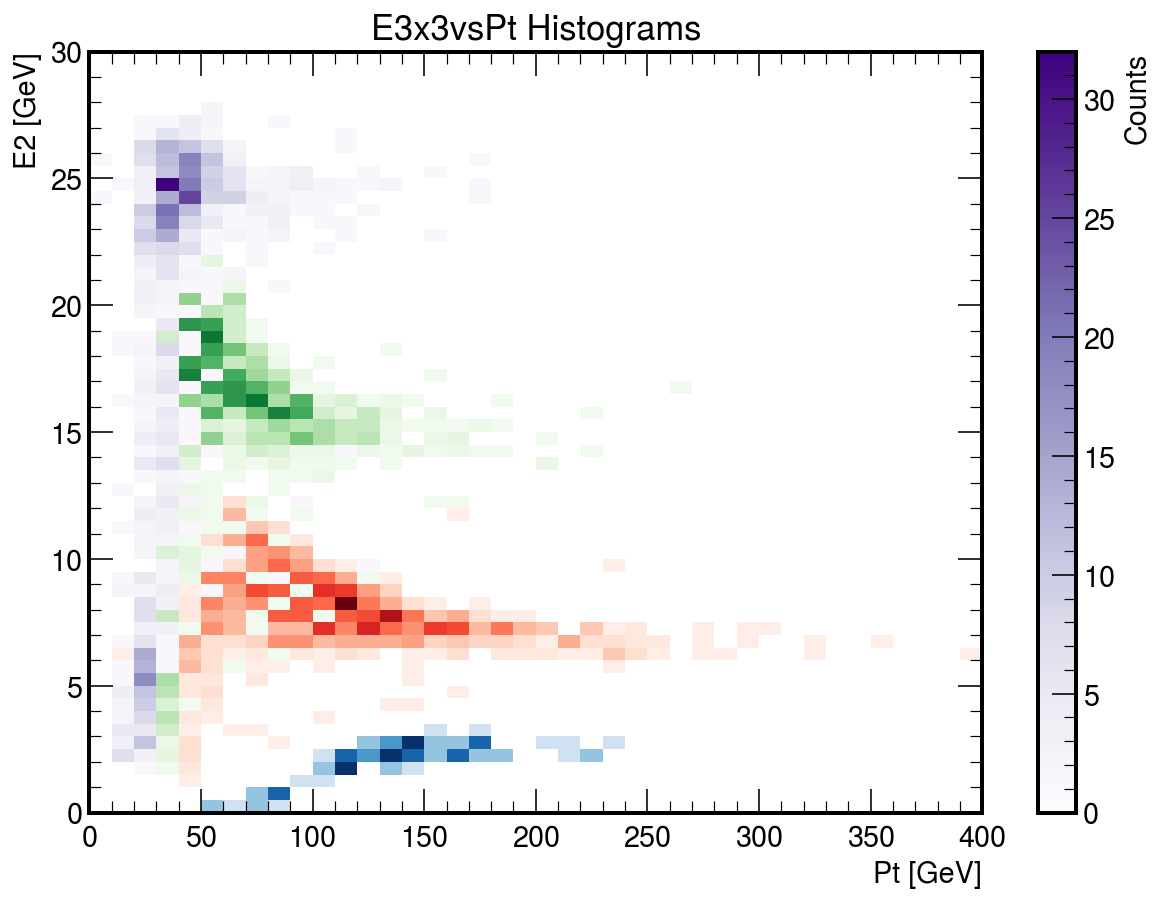

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


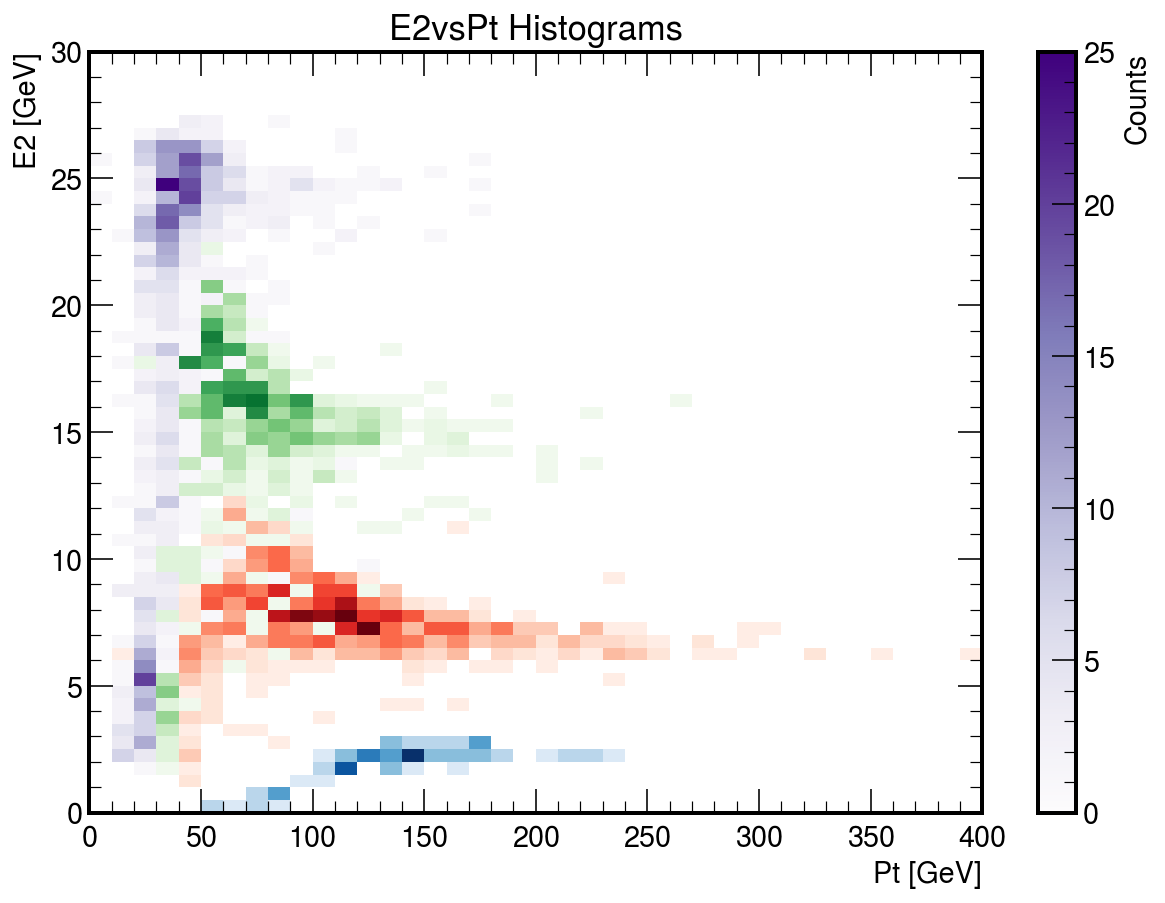

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


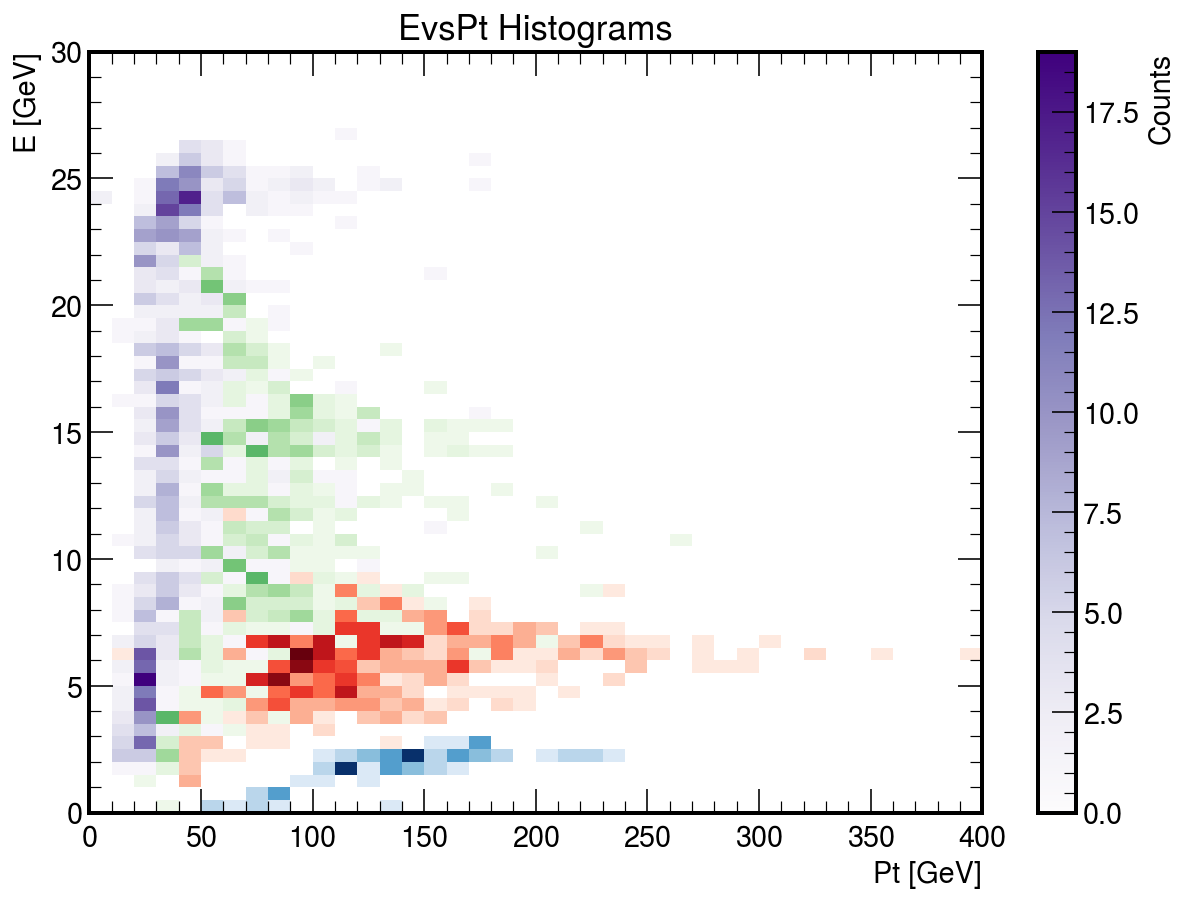

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


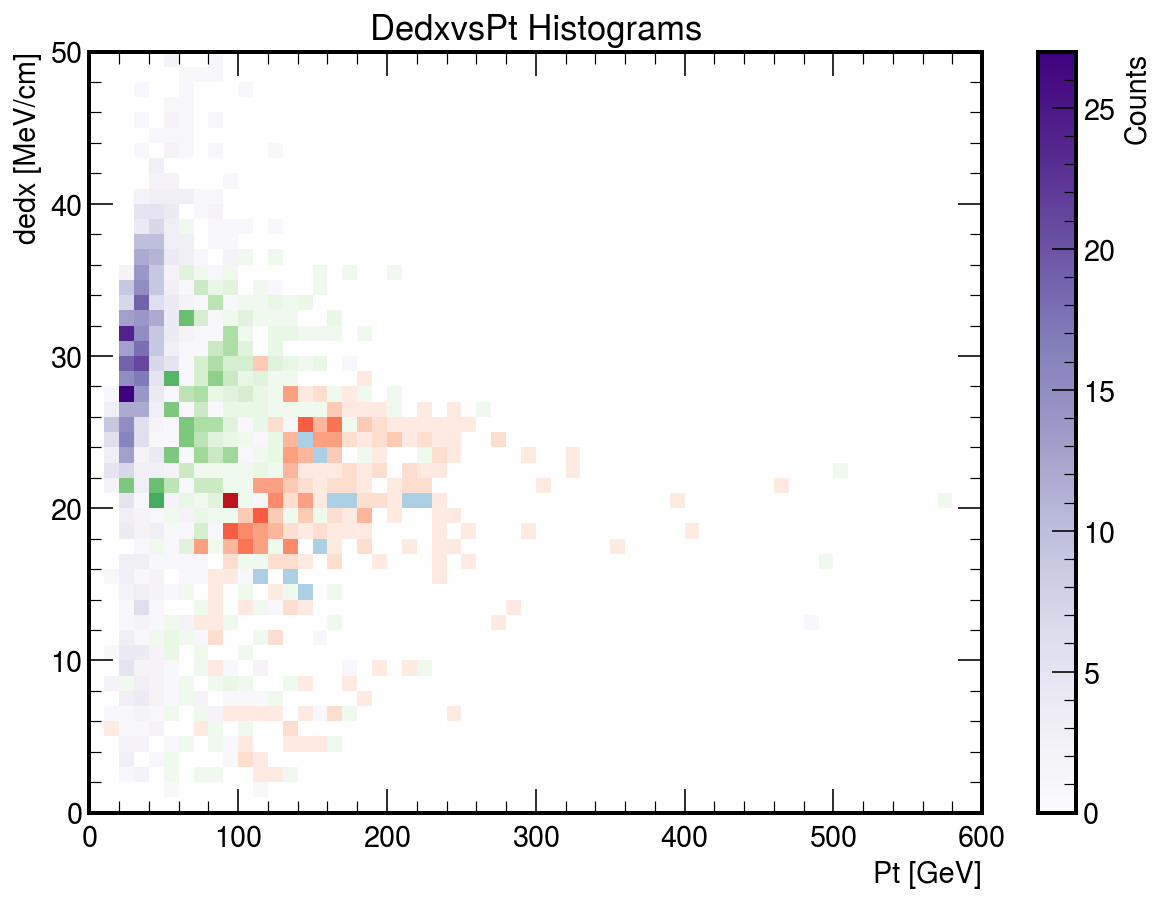

In [31]:
charges = [2,5,9,14] 
masses = [900] 

plot_2Dhistograms_pkl(data, ('E3x3vsPt', 'Pt [GeV]', 'E2 [GeV]'), charges, masses)
plot_2Dhistograms_pkl(data, ('E2vsPt', 'Pt [GeV]', 'E2 [GeV]'), charges, masses)
plot_2Dhistograms_pkl(data, ('EvsPt', 'Pt [GeV]', 'E [GeV]'), charges, masses)
plot_2Dhistograms_pkl(data, ('DedxvsPt', 'Pt [GeV]', 'dedx [MeV/cm]'), charges, masses)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


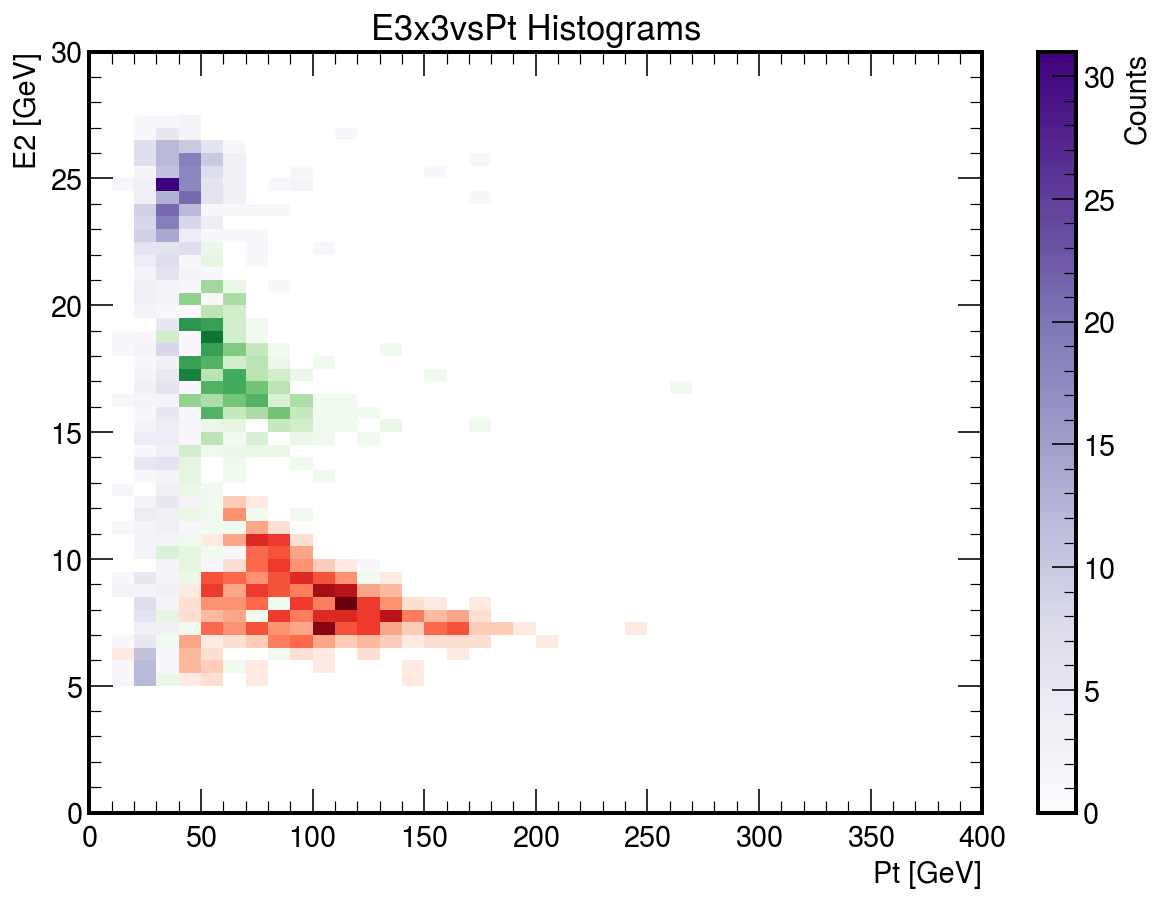

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


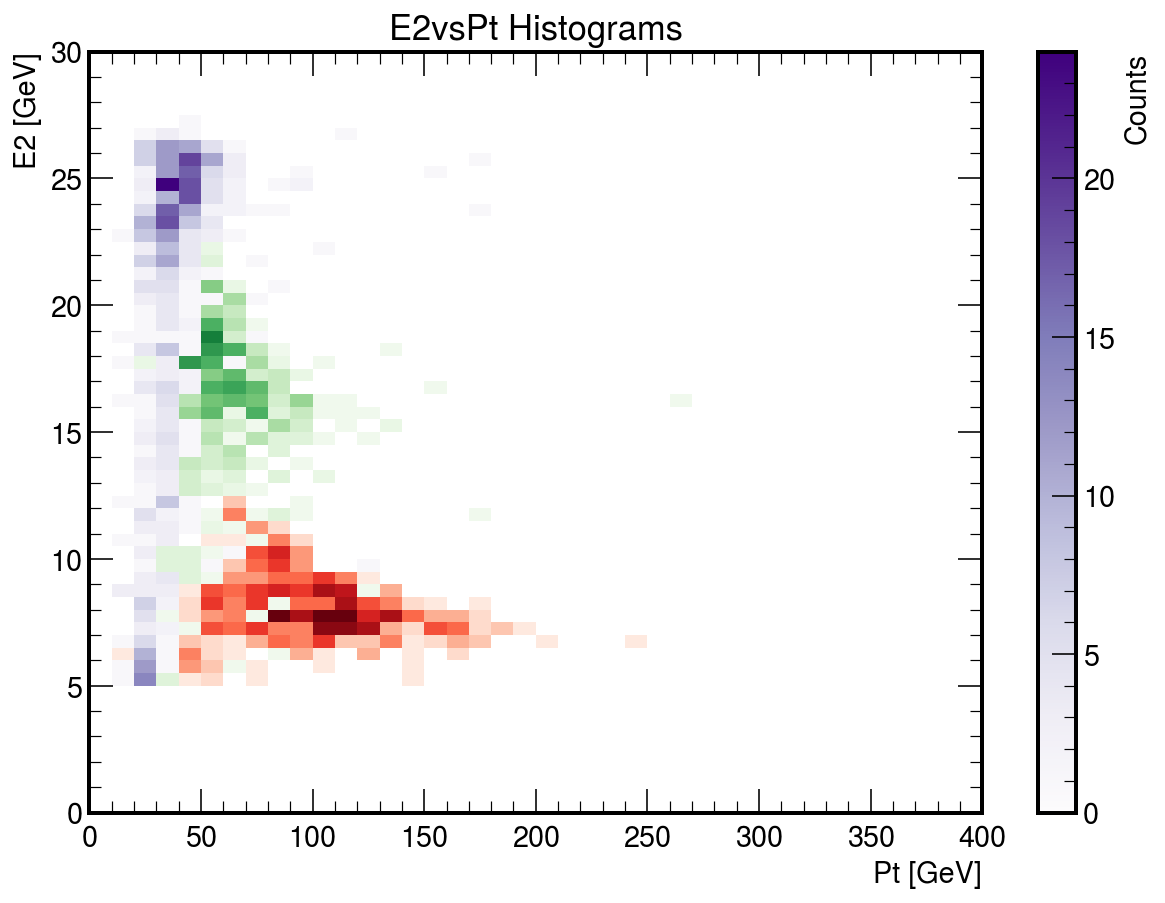

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


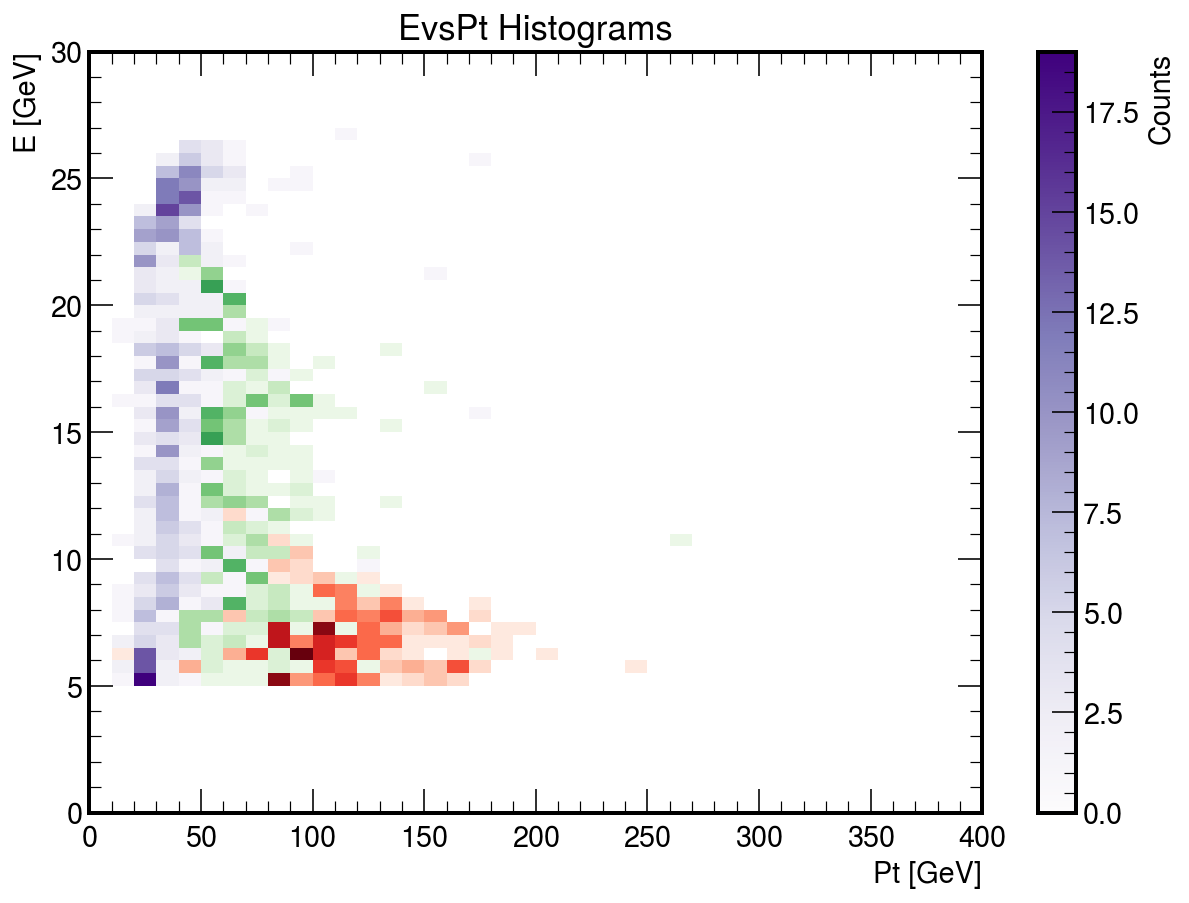

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


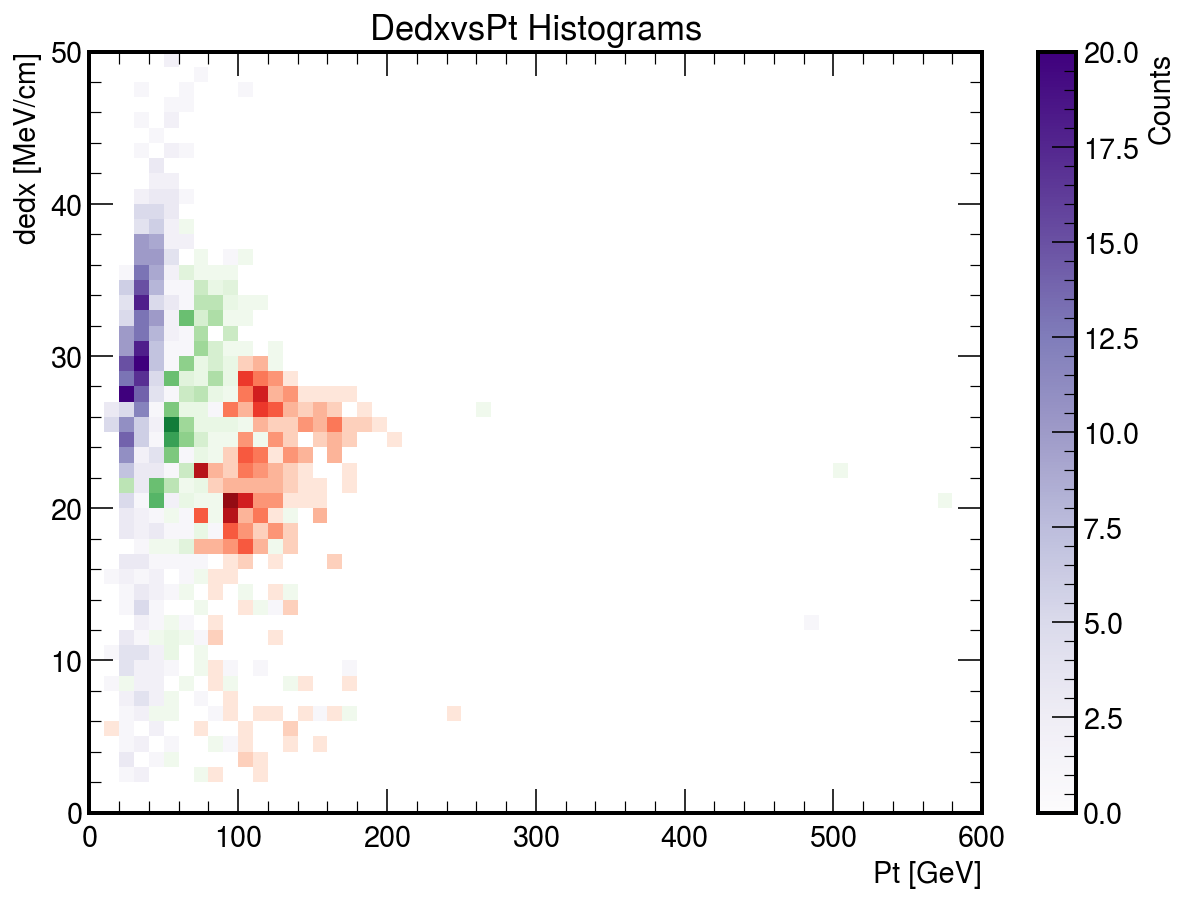

In [56]:
charges = [2,5,9,14] 
masses = [900] 

plot_2Dhistograms_pkl(data, ('E3x3vsPt', 'Pt [GeV]', 'E2 [GeV]'), charges, masses)
plot_2Dhistograms_pkl(data, ('E2vsPt', 'Pt [GeV]', 'E2 [GeV]'), charges, masses)
plot_2Dhistograms_pkl(data, ('EvsPt', 'Pt [GeV]', 'E [GeV]'), charges, masses)
plot_2Dhistograms_pkl(data, ('DedxvsPt', 'Pt [GeV]', 'dedx [MeV/cm]'), charges, masses)

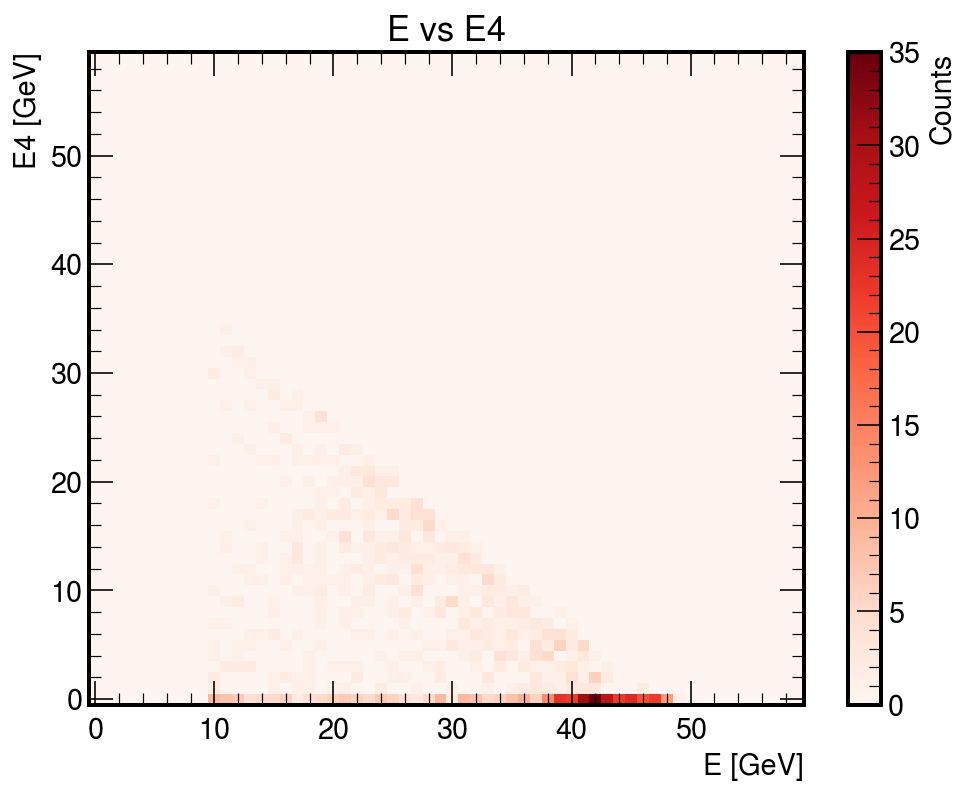

In [93]:
hist_data = data['Q12_M2000']['EvsE4'].view()

plt.figure(figsize=(8, 6))
plt.imshow(hist_data, aspect='auto', origin='lower', cmap='Reds')
plt.colorbar(label='Counts')
plt.xlabel('E [GeV]')  
plt.ylabel('E4 [GeV]')  
plt.title('E vs E4')
plt.show()

(array([89.,  8.,  5.,  2.,  2.,  2.,  0.,  2.,  2.,  0.,  0.,  1.,  1.,
         1.,  0.,  0.,  1.,  1.,  1.,  2.]),
 array([ 0.  ,  4.15,  8.3 , 12.45, 16.6 , 20.75, 24.9 , 29.05, 33.2 ,
        37.35, 41.5 , 45.65, 49.8 , 53.95, 58.1 , 62.25, 66.4 , 70.55,
        74.7 , 78.85, 83.  ]),
 <BarContainer object of 20 artists>)

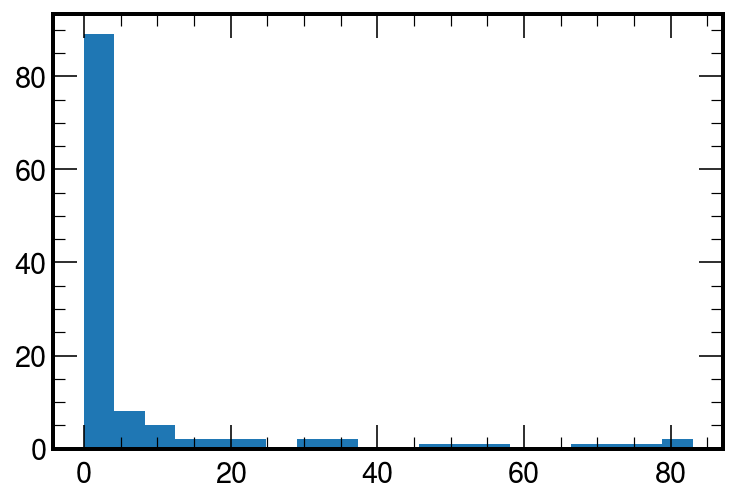

In [87]:
#plt.hist(data['Q10_M900']['E2'].view(), bins=20)
#plt.hist(data['Q10_M900']['E4'].view())
#plt.hist(data['Q10_M900']['E3x3'].view())

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


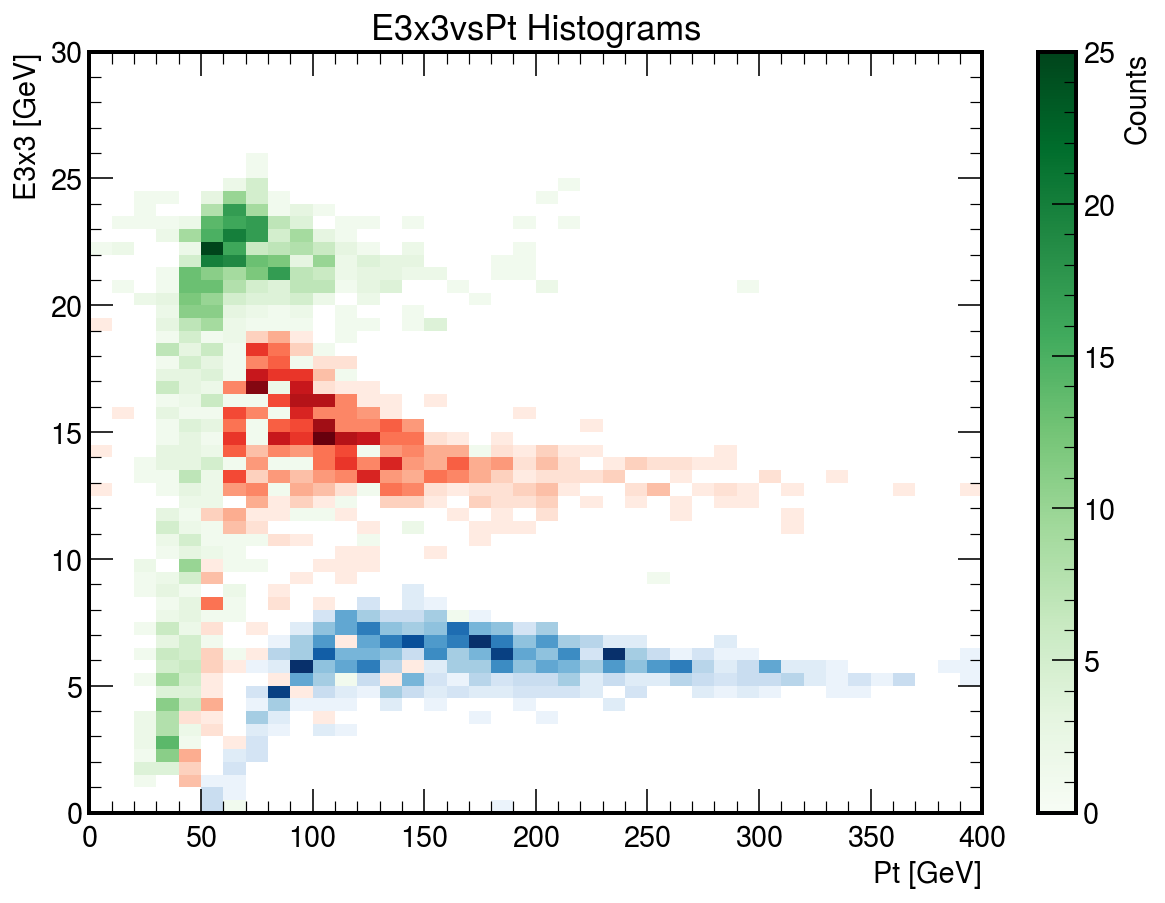

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


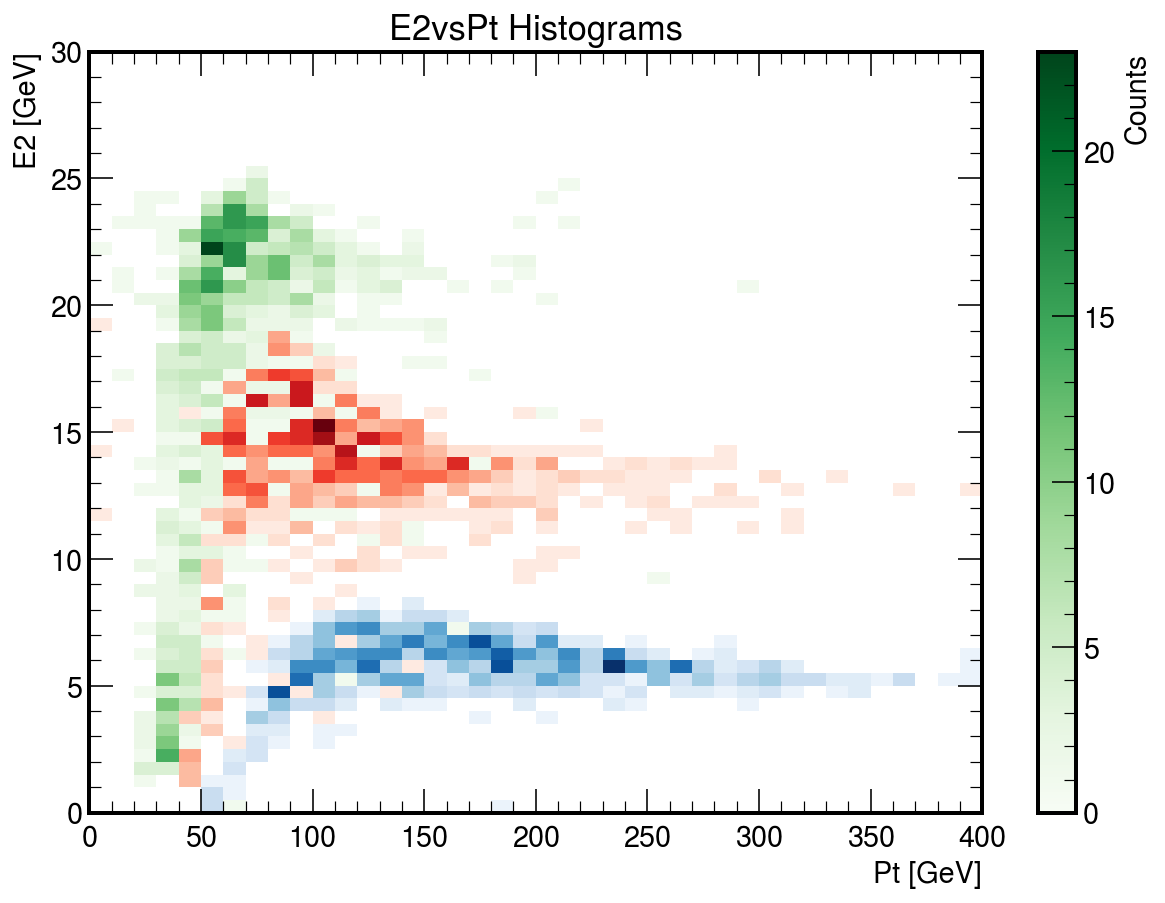

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


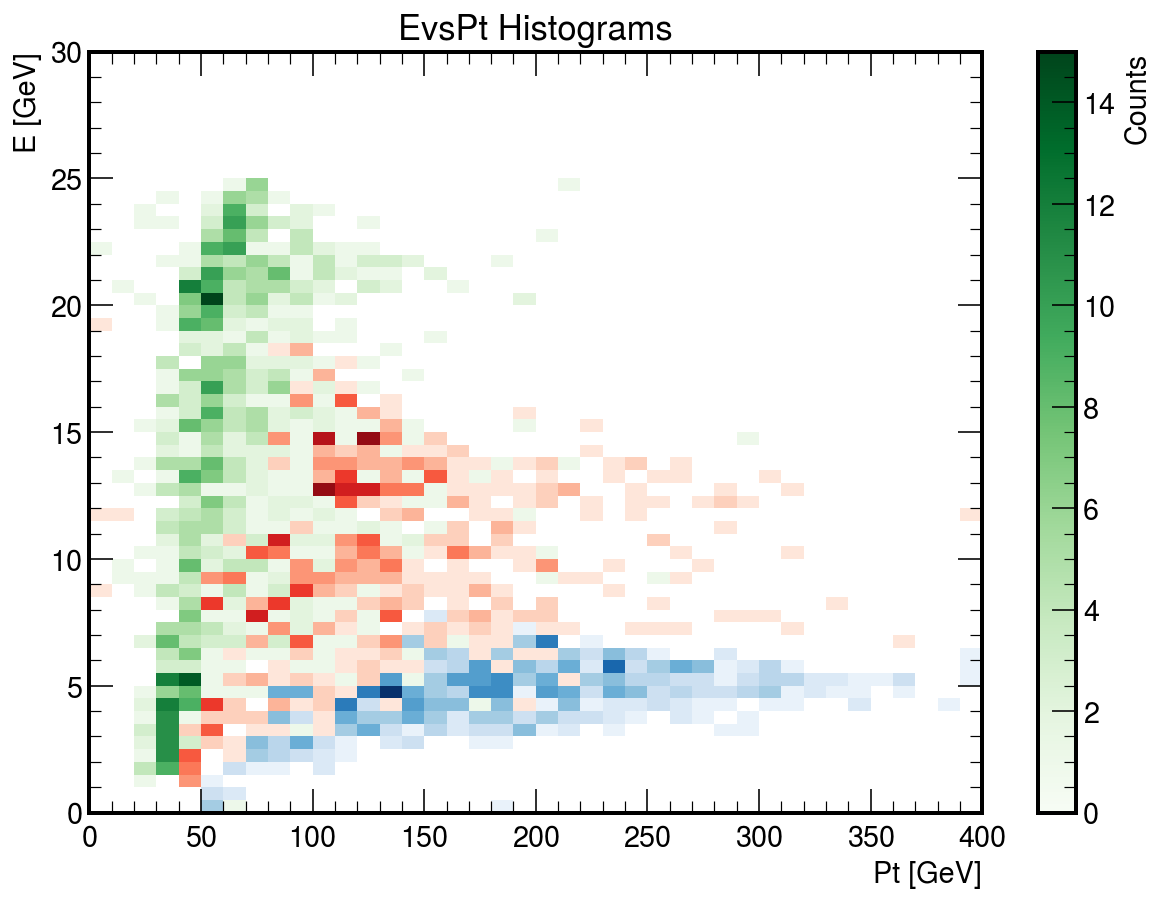

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


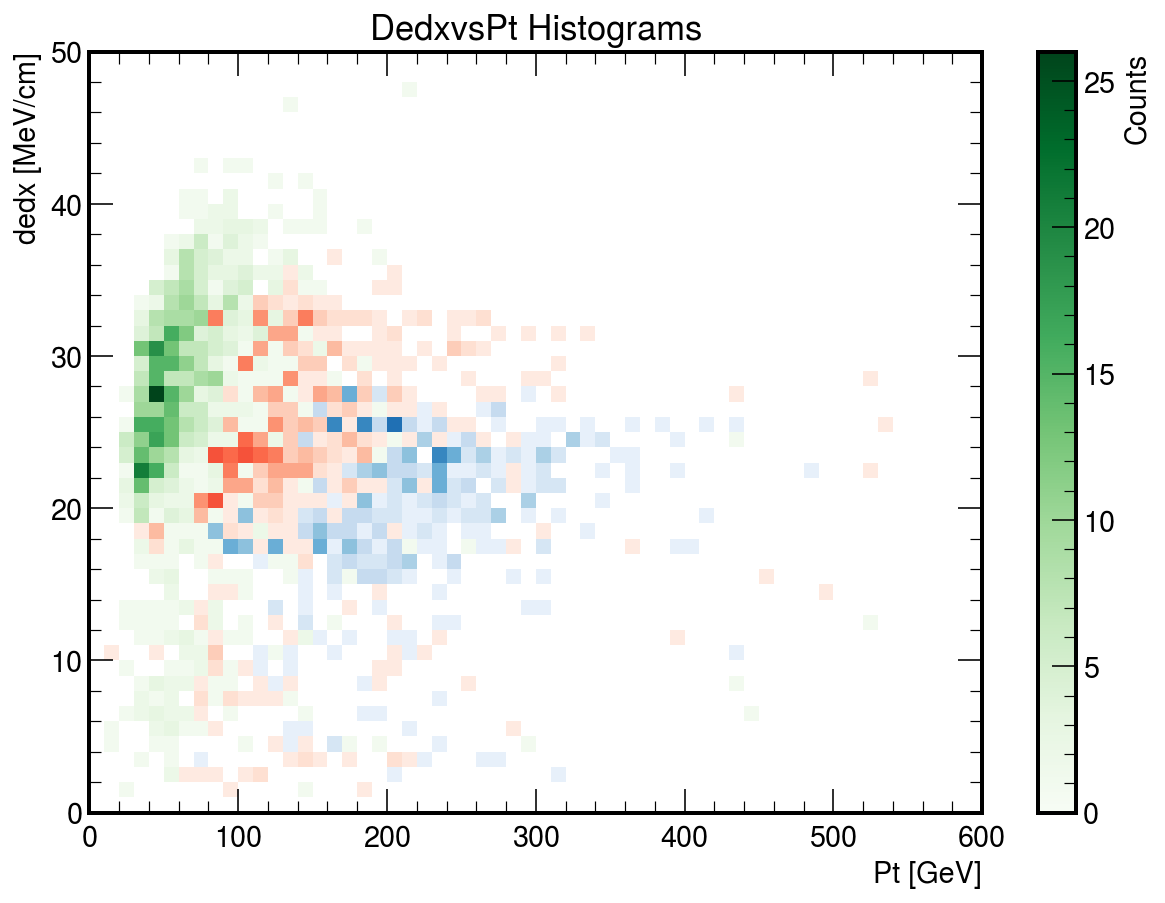

In [30]:
charges = [4,8,12] 
masses = [1400] 

plot_2Dhistograms_pkl(data, ('E3x3vsPt', 'Pt [GeV]', 'E3x3 [GeV]'), charges, masses)
plot_2Dhistograms_pkl(data, ('E2vsPt', 'Pt [GeV]', 'E2 [GeV]'), charges, masses)
plot_2Dhistograms_pkl(data, ('EvsPt', 'Pt [GeV]', 'E [GeV]'), charges, masses)
plot_2Dhistograms_pkl(data, ('DedxvsPt', 'Pt [GeV]', 'dedx [MeV/cm]'), charges, masses)